# Notebook 3 — Model the trips & produce the KPI (12 months of 2023)
~90 s to run.

*What you'll see:* what one trip really contains, the fact model, the **5 metrics across 12
months**, whether the year-on-year movement is real or a trip-mix illusion, where time is lost
(hours **and zones**), and the KPI chain. Association ≠ causation — no traffic feed exists (L3).
Inputs: `data/facts/*.parquet` + `output/metrics_*.csv`.

**Load the published metric outputs** (definitions live in `src/nyc_pipeline/metrics.py`
so notebooks can never disagree with production).

In [1]:
import json, sys
from pathlib import Path
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
pd.set_option("display.width", 175)

for base in [Path.cwd(), Path.cwd().parent]:
    if (base / "src" / "nyc_pipeline").exists():
        sys.path.insert(0, str(base / "src")); ROOT = base; break

monthly = pd.read_csv(ROOT / "output/metrics_monthly_wide.csv")
hourly  = pd.read_csv(ROOT / "output/metrics_hourly_detail.csv")
zones   = pd.read_csv(ROOT / "output/metrics_zone_detail.csv")
FACTS   = f"read_parquet('{ROOT}/data/facts/*.parquet')"
display(monthly.round(4))

,month,valid_trip_rate,invalid_trip_rate,raw_rows,valid_rows,quarantined_rows,duration_p50_min,duration_p90_min,slow_trip_share,trip_time_reliability
0,2023-01,0.9850,0.0150,3066726,3020708,46018,11.58,27.93,0.0877,0.8002
1,2023-02,0.9857,0.0143,2914003,2872379,41624,11.87,28.47,0.0978,0.7743
2,2023-03,0.9856,0.0144,3403660,3354652,49008,12.22,30.73,0.1194,0.7411
3,2023-04,0.9877,0.0123,3288248,3247736,40512,12.43,31.80,0.1213,0.7337
4,2023-05,0.9866,0.0134,3513664,3466532,47132,13.07,33.97,0.1478,0.6864
5,2023-06,0.9855,0.0145,3307259,3259399,47860,12.88,33.50,0.1401,0.6994
6,2023-07,0.9828,0.0172,2907093,2856951,50142,12.48,32.13,0.1274,0.7338
7,2023-08,0.9796,0.0204,2824201,2766461,57740,12.50,32.25,0.1147,0.7443
8,2023-09,0.9653,0.0347,2846741,2747891,98850,13.67,36.48,0.1955,0.6329
9,2023-10,0.9654,0.0346,3522269,3400335,121934,13.58,34.85,0.1848,0.6398


**One trip, end to end** — a fast, a typical and a slow trip from Dec 2023. Only pickup,
dropoff, distance and **zone ids** are observed; duration, speed, band and bucket are derived
once in the pipeline; traffic, driver and request never existed in this data.

In [2]:
t = duckdb.sql(f"""
WITH trips AS (
  SELECT *, ROW_NUMBER() OVER (ORDER BY duration_min ASC) AS rn_fast,
            ROW_NUMBER() OVER (ORDER BY abs(duration_min - 13)) AS rn_mid,
            ROW_NUMBER() OVER (ORDER BY duration_min DESC) AS rn_slow
  FROM {FACTS} WHERE month = '2023-12')
SELECT pickup_zone_id, pickup_ts, dropoff_ts, round(duration_min,1) AS duration_min,
       distance_mi, round(speed_mph,1) AS speed_mph, distance_band, time_bucket,
       CASE WHEN rn_fast=1 THEN 'fastest' WHEN rn_mid=1 THEN 'typical' WHEN rn_slow=1 THEN 'slowest' END AS pick
FROM trips WHERE rn_fast=1 OR rn_mid=1 OR rn_slow=1 ORDER BY duration_min
""").df()
display(t)
print("observed: pickup/dropoff times, distance, TLC zone ids | derived: duration, speed, band, bucket")

,pickup_zone_id,pickup_ts,dropoff_ts,duration_min,distance_mi,speed_mph,distance_band,time_bucket,pick
0,132,2023-12-11 17:38:22,2023-12-11 17:38:23,0.0,28.00,100800.0,f_20mi_plus,pm_peak_16-20,fastest
1,170,2023-12-09 18:44:00,2023-12-09 18:57:00,13.0,1.69,7.8,b_1-2mi,pm_peak_16-20,typical
2,132,2023-12-27 13:34:21,2023-12-28 13:34:17,1439.9,11.40,0.5,e_10-20mi,midday_10-16,slowest


observed: pickup/dropoff times, distance, TLC zone ids | derived: duration, speed, band, bucket


**The model and its grain** — one row = one valid trip (no trip ID exists, so the guard is
row conservation + the duplicate audit). The baseline table is the KPI's ruler: "expected
minutes" per distance band × time-of-day cell, learned from Jan 2023 (assumption A4).

In [3]:
display(duckdb.sql(f"""
SELECT month, count(*) AS fact_rows, min(pickup_ts) AS first_pickup, max(pickup_ts) AS last_pickup
FROM {FACTS} GROUP BY 1 ORDER BY 1""").df())
exp = pd.read_csv(ROOT / "output/expected_duration_baseline.csv")
display(exp.pivot(index="distance_band", columns="time_bucket", values="expected_duration_min"))

,month,fact_rows,first_pickup,last_pickup
0,2023-01,3020708,2023-01-01 00:00:00,2023-01-31 23:59:59
1,2023-02,2872379,2023-02-01 00:00:00,2023-02-28 23:59:59
2,2023-03,3354652,2023-03-01 00:00:00,2023-03-31 23:59:59
3,2023-04,3247736,2023-04-01 00:00:00,2023-04-30 23:59:57
4,2023-05,3466532,2023-05-01 00:00:06,2023-05-31 23:59:56
5,2023-06,3259399,2023-06-01 00:00:00,2023-06-30 23:59:59
6,2023-07,2856951,2023-07-01 00:00:01,2023-07-31 23:59:55
7,2023-08,2766461,2023-08-01 00:00:00,2023-08-31 23:59:59
8,2023-09,2747891,2023-09-01 00:00:00,2023-09-30 23:59:59
9,2023-10,3400335,2023-10-01 00:00:00,2023-10-31 23:59:58


time_bucket,am_peak_06-10,evening_20-24,midday_10-16,overnight_00-06,pm_peak_16-20
distance_band,,,,,
a_0-1mi,7.33,6.48,7.97,5.68,7.70
b_1-2mi,12.68,10.95,13.87,9.77,13.33
c_2-5mi,20.75,18.75,22.97,16.90,22.43
d_5-10mi,30.05,26.70,31.20,26.00,32.27
e_10-20mi,51.57,36.44,51.03,33.90,51.75
f_20mi_plus,64.32,43.93,63.39,43.55,61.17


**The 5 metrics** — M2 is the KPI; M3 explains it, M5 drives it, M1/M4 gate it. Each
carries its formula and KPI link inside `METRICS` (emitted to the evidence table).

In [4]:
from nyc_pipeline.metrics import METRICS
display(pd.DataFrame([{"id": k, "name": v["name"], "grain": v["grain"], "link": v["kpi_link"]}
                      for k, v in METRICS.items()]))
long = pd.read_csv(ROOT / "output/metrics_monthly.csv")
display(long.pivot_table(index="month", columns="metric_name", values="value").round(4))

,id,name,grain,link
0,M1,valid_trip_rate,month,gating metric — KPI is only published while M1...
1,M2,trip_time_reliability,month,PROJECT KPI — this is the number leadership tr...
2,M3,trip_duration_typical,month (detail by hour),outcome detail — explains moves in M2
3,M4,invalid_trip_rate,month,"supporting — protects M2's denominator, must b..."
4,M5,slow_trip_share,month (detail by hour),driver metric — hours with high M5 have low M2


metric_name,invalid_trip_rate,slow_trip_share,trip_duration_typical,trip_duration_typical_p90,trip_time_reliability,valid_trip_rate
month,,,,,,
2023-01,0.0150,0.0877,11.58,27.93,0.8002,0.9850
2023-02,0.0143,0.0978,11.87,28.47,0.7743,0.9857
2023-03,0.0144,0.1194,12.22,30.73,0.7411,0.9856
2023-04,0.0123,0.1213,12.43,31.80,0.7337,0.9877
2023-05,0.0134,0.1478,13.07,33.97,0.6864,0.9866
2023-06,0.0145,0.1401,12.88,33.50,0.6994,0.9855
2023-07,0.0172,0.1274,12.48,32.13,0.7338,0.9828
2023-08,0.0204,0.1147,12.50,32.25,0.7443,0.9796
2023-09,0.0347,0.1955,13.67,36.48,0.6329,0.9653


**The KPI across the year** — left: reliability (M2) with its driver (M5 slow share);
right: the distance-band ruler. Saved as `output/fig_metrics_overview.png`.

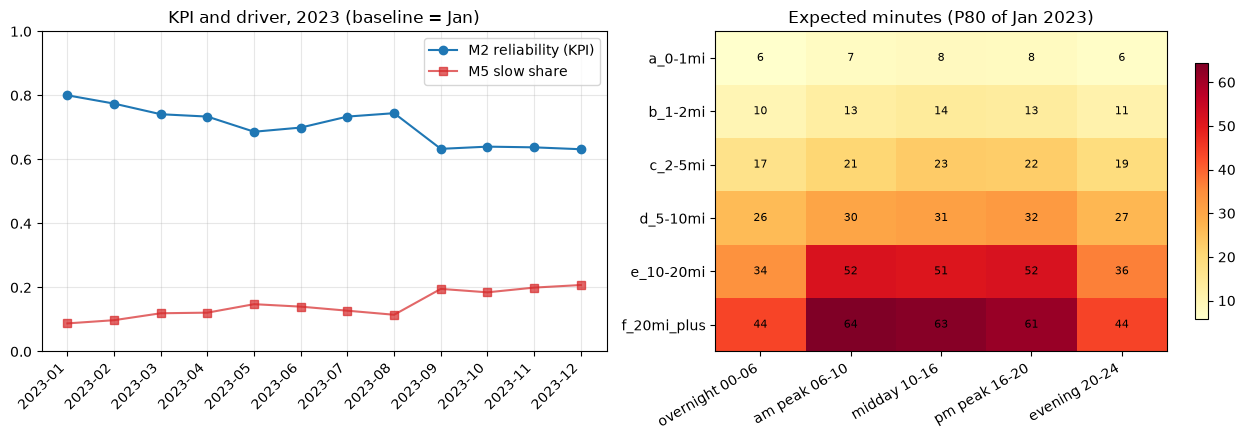

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(monthly["month"], monthly["trip_time_reliability"], marker="o",
           color="tab:blue", label="M2 reliability (KPI)")
ax[0].plot(monthly["month"], monthly["slow_trip_share"], marker="s",
           color="tab:red", alpha=.7, label="M5 slow share")
ax[0].set_title("KPI and driver, 2023 (baseline = Jan)"); ax[0].set_ylim(0, 1)
ax[0].legend(); ax[0].grid(alpha=.3); plt.setp(ax[0].get_xticklabels(), rotation=45, ha="right")
b = exp.pivot(index="distance_band", columns="time_bucket", values="expected_duration_min")
order = ["overnight_00-06", "am_peak_06-10", "midday_10-16", "pm_peak_16-20", "evening_20-24"]
im = ax[1].imshow(b[order].values, cmap="YlOrRd", aspect="auto")
ax[1].set_xticks(range(len(order)), [o.replace("_", " ") for o in order], rotation=30, ha="right")
ax[1].set_yticks(range(len(b)), b.index)
ax[1].set_title("Expected minutes (P80 of Jan 2023)")
for i in range(b.shape[0]):
    for j in range(b.shape[1]):
        ax[1].text(j, i, f"{b[order].values[i, j]:.0f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax[1], shrink=.8)
plt.tight_layout(); plt.savefig(ROOT / "output/fig_metrics_overview.png", dpi=120); plt.show()

**Is the decline real, or a trip-mix illusion?** Reliability falls from 80.0% (Jan) to
63.2% (Dec). If December simply had *more long/airport trips* than January, the fall could be
composition rather than congestion — so we reweight every month to January's distance-band mix
and compare. The gap is ≤0.15 points: **the slowdown is real within every band**, not a mix
effect. (This is a Simpson's-paradox guard; it is analysis, not a published metric.)

In [6]:
band = duckdb.sql(f"""
SELECT f.month, f.distance_band,
       avg(CASE WHEN f.duration_min <= e.expected_duration_min THEN 1.0 ELSE 0 END) AS rel
FROM {FACTS} f JOIN read_csv_auto('{(ROOT / "output/expected_duration_baseline.csv")}') e
  ON f.distance_band = e.distance_band AND f.time_bucket = e.time_bucket
GROUP BY 1, 2""").df()
mix = duckdb.sql(f"""
SELECT month, distance_band, count(*) AS n FROM {FACTS} GROUP BY 1, 2""").df()
jan_mix = mix[mix.month == "2023-01"].set_index("distance_band")["n"]
jan_mix = jan_mix / jan_mix.sum()
rows = []
for m, g in band.groupby("month"):
    g = g.set_index("distance_band")
    rows.append({"month": m,
                 "mix_adjusted": float((g["rel"] * jan_mix.reindex(g.index)).sum())})
adj = pd.DataFrame(rows).merge(monthly[["month", "trip_time_reliability"]], on="month")
adj["gap_pts"] = (adj["trip_time_reliability"] - adj["mix_adjusted"]) * 100
display(adj.round(4))
print(f"largest gap: {adj['gap_pts'].abs().max():.2f} pts → the year-on-year movement is NOT composition")

,month,mix_adjusted,trip_time_reliability,gap_pts
0,2023-01,0.8002,0.8002,0.0000
1,2023-02,0.7742,0.7743,0.0064
2,2023-03,0.7413,0.7411,-0.0200
3,2023-04,0.7345,0.7337,-0.0772
4,2023-05,0.6877,0.6864,-0.1280
5,2023-06,0.7008,0.6994,-0.1428
6,2023-07,0.7345,0.7338,-0.0789
7,2023-08,0.7458,0.7443,-0.1449
8,2023-09,0.6333,0.6329,-0.0383
9,2023-10,0.6398,0.6398,-0.0019


largest gap: 0.14 pts → the year-on-year movement is NOT composition


**Where the time goes — hours and zones** (Dec 2023). Every statement here is
*association*: we can say slow trips cluster at midday in Midtown, never that traffic caused it.

In [7]:
h = hourly[hourly.month == "2023-12"]
print("Worst 5 pickup hours, Dec 2023:")
display(h.sort_values("slow_share", ascending=False).head(5)[
    ["hour", "trips", "duration_p50_min", "duration_p90_min", "slow_share",
     "trip_time_reliability"]].round(4))

z = zones[(zones.month == "2023-12") & zones.rankable]
print("Worst 5 pickup zones, Dec 2023:")
display(z.nsmallest(5, "trip_time_reliability")[
    ["pickup_zone", "borough", "trips", "trip_time_reliability", "slow_trip_share",
     "duration_p90_min"]].round(3))

Worst 5 pickup hours, Dec 2023:


,hour,trips,duration_p50_min,duration_p90_min,slow_share,trip_time_reliability
279,15,211377,15.08,43.82,0.2930,0.5632
278,14,202387,15.18,42.15,0.2891,0.5783
281,17,220403,14.67,40.58,0.2891,0.5554
280,16,206571,15.08,44.95,0.2855,0.5453
277,13,189982,14.47,37.38,0.2832,0.6164


Worst 5 pickup zones, Dec 2023:


,pickup_zone,borough,trips,trip_time_reliability,slow_trip_share,duration_p90_min
2984,Penn Station/Madison Sq West,Manhattan,110988,0.444,0.384,33.45
2902,Garment District,Manhattan,53614,0.478,0.376,31.27
2872,East Chelsea,Manhattan,89235,0.500,0.307,32.77
2959,Midtown Center,Manhattan,144381,0.512,0.348,29.60
3026,Times Sq/Theatre District,Manhattan,110249,0.515,0.308,35.72


**Airport vs city, and a map of the KPI.** Airports are ~5% of trips and slide hardest
(80.0% → 58.5% reliability). The choropleth shows reliability by pickup zone; white = too few
trips to rank. Saved as `output/fig_zone_map.png`.

,month,segment,trips,share_of_trips,trip_time_reliability,duration_p50_min,slow_trip_share
0,2023-01,airport_zone,156678,0.0519,0.8004,35.38,0.0070
1,2023-01,city_zone,2824963,0.9352,0.7999,11.12,0.0924
2,2023-01,zone_unknown,39067,0.0129,0.8212,15.17,0.0773
33,2023-12,airport_zone,147996,0.0448,0.5849,41.80,0.0080
34,2023-12,city_zone,3141491,0.9511,0.6339,12.90,0.2171
35,2023-12,zone_unknown,13526,0.0041,0.6507,13.04,0.1880


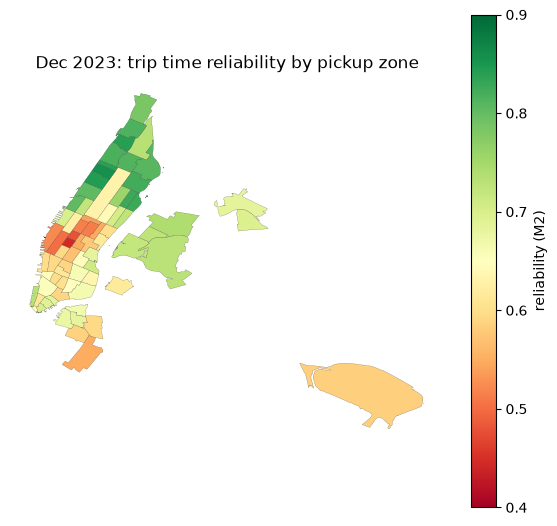

In [8]:
seg = pd.read_csv(ROOT / "output/metrics_segments.csv")
display(seg[seg.month.isin(["2023-01", "2023-12"])][
    ["month", "segment", "trips", "share_of_trips", "trip_time_reliability",
     "duration_p50_min", "slow_trip_share"]].round(4))

import numpy as np
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPoly
from shapely.geometry import shape
feats = json.loads((ROOT / "data/reference/taxi_zone_shapes/page_0001.json").read_text())
rel = dict(zip(z.pickup_zone_id, z.trip_time_reliability))
patches, colors = [], []
for f in feats:
    lid = int(f["locationid"])
    if lid not in rel:
        continue
    g = shape(f["the_geom"])
    for poly in (g.geoms if g.geom_type == "MultiPolygon" else [g]):
        patches.append(MplPoly(np.array(poly.exterior.coords), closed=True))
        colors.append(rel[lid])
pc = PatchCollection(patches, cmap="RdYlGn", edgecolor="k", linewidths=.1)
pc.set_array(np.array(colors)); pc.set_clim(.40, .90)
fig, ax = plt.subplots(figsize=(7, 8))
ax.add_collection(pc); ax.autoscale(); ax.set_aspect("equal"); ax.axis("off")
plt.colorbar(pc, ax=ax, shrink=.8, label="reliability (M2)")
ax.set_title("Dec 2023: trip time reliability by pickup zone")
plt.savefig(ROOT / "output/fig_zone_map.png", dpi=120, bbox_inches="tight"); plt.show()

**KPI chain + honest limits** — what feeds the headline, what we may and may not claim,
and the client sign-offs still needed before the number is unconditional.

In [9]:
print("PROJECT KPI (M2 trip time reliability)")
print("  ├─ outcome : M3 duration P50/P90          └─ driver : M5 slow share by hour")
print("  ├─ detail  : zone table + airport/city segments (native TLC zone ids)")
print("  └─ gates   : M1 valid rate · M4 invalid rate → may we publish?")
print("       └─ events: pickup & dropoff timestamps, distance, zone (the only observed lifecycle)")
print("\nCannot claim: causes (no traffic feed, L3), money accuracy (L5), season-adjusted")
print("trend (L4 — 12 months make seasonality visible but not removable), or precision for")
print("the 1% of trips whose zone is 'Unknown' (L2).")
print("Before unconditional publish: client signs off A3 (24h cap), A4 (P80 baseline), A6/A7 (U5 cohort).")

PROJECT KPI (M2 trip time reliability)
  ├─ outcome : M3 duration P50/P90          └─ driver : M5 slow share by hour
  ├─ detail  : zone table + airport/city segments (native TLC zone ids)
  └─ gates   : M1 valid rate · M4 invalid rate → may we publish?
       └─ events: pickup & dropoff timestamps, distance, zone (the only observed lifecycle)

Cannot claim: causes (no traffic feed, L3), money accuracy (L5), season-adjusted
trend (L4 — 12 months make seasonality visible but not removable), or precision for
the 1% of trips whose zone is 'Unknown' (L2).
Before unconditional publish: client signs off A3 (24h cap), A4 (P80 baseline), A6/A7 (U5 cohort).
